In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis

from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay
from sklearn.preprocessing import TargetEncoder, StandardScaler, OneHotEncoder, LabelEncoder, label_binarize

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [5]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
health_condition,690088.0,1.025969,0.375035,0.0,1.00,1.00,1.00,2.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


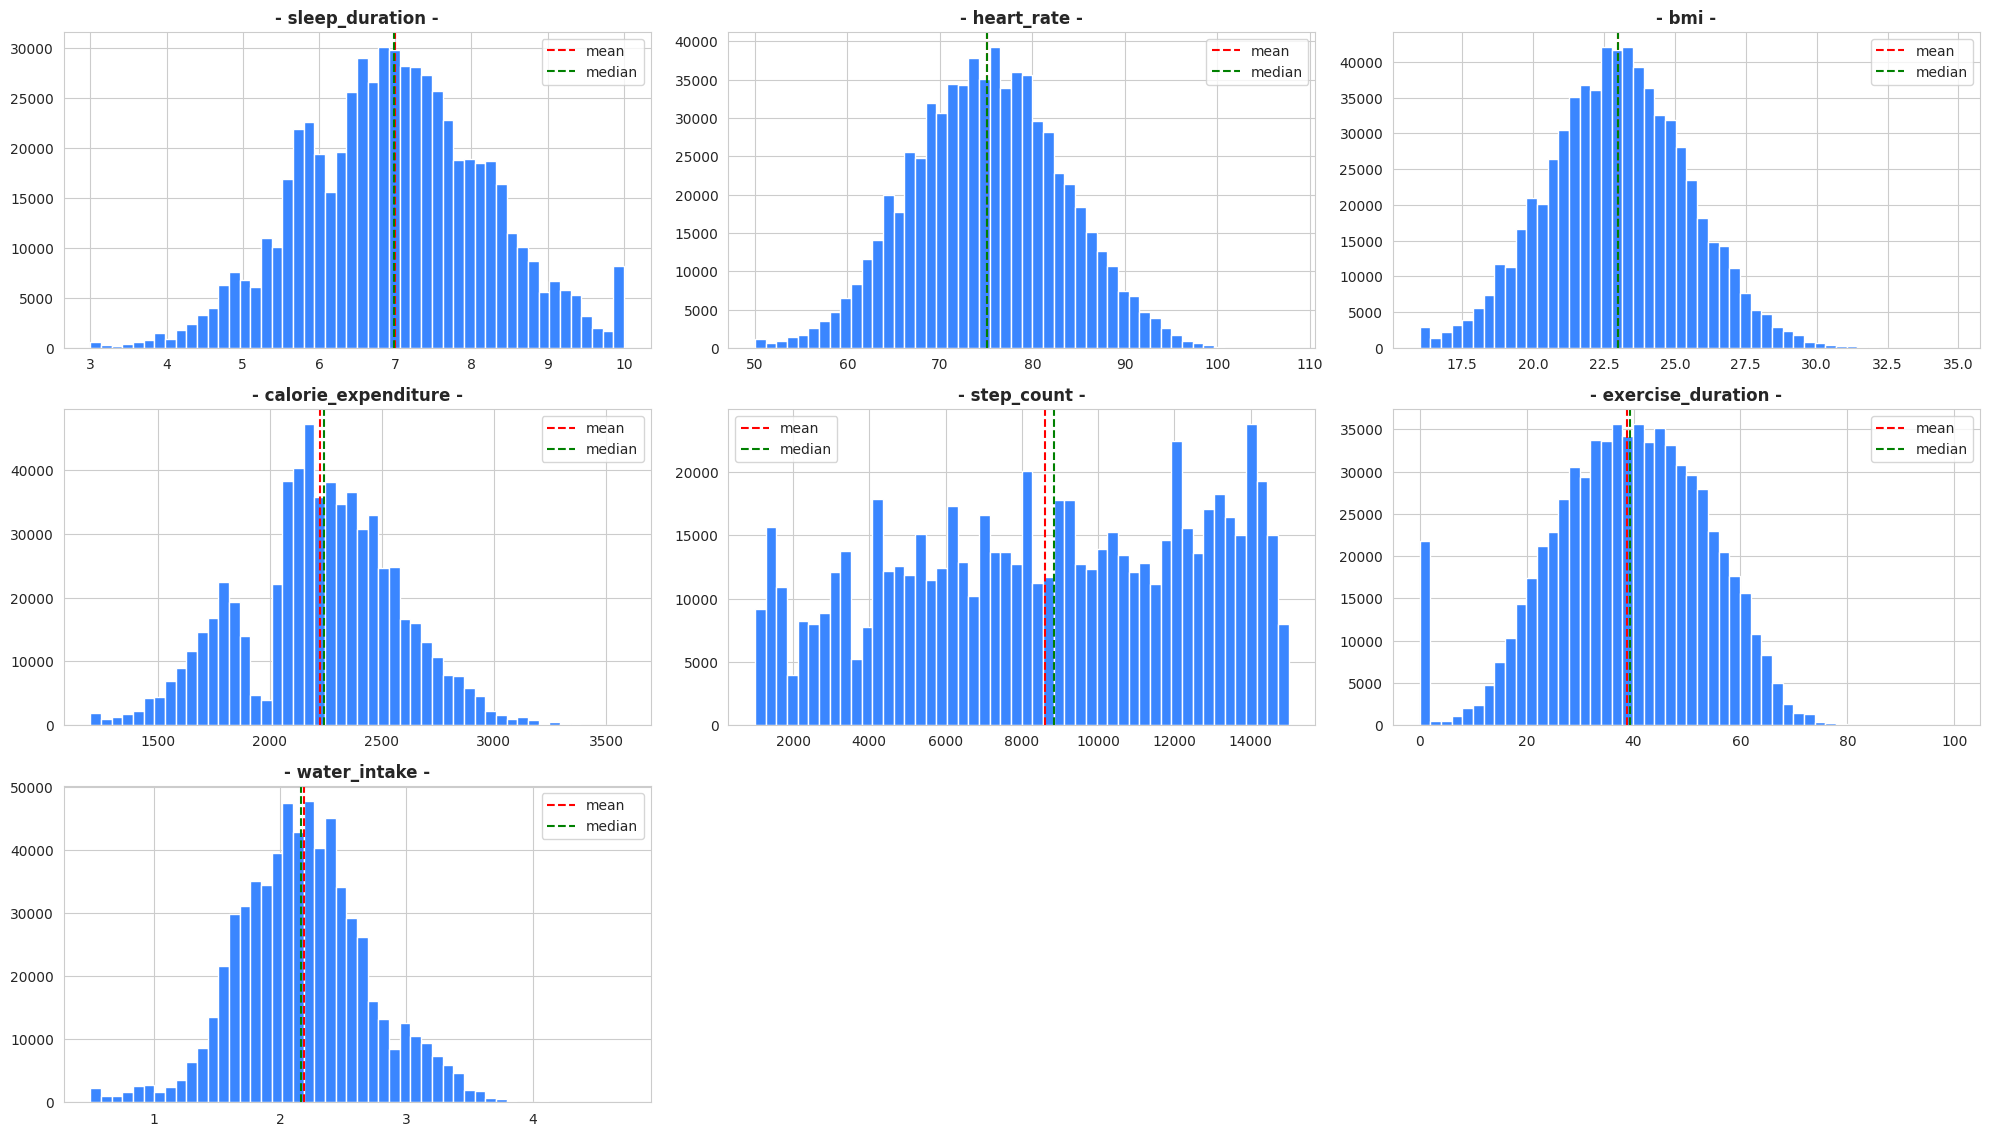

In [7]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

In [8]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


In [9]:
n_unique = train[BASE].nunique().sort_values()
n_unique

diet_type                      3
physical_activity_level        3
sleep_quality                  3
gender                         3
smoking_alcohol                3
stress_level                   3
water_intake                 400
heart_rate                   537
sleep_duration               701
exercise_duration            856
bmi                         1596
calorie_expenditure         2101
step_count                 12807
dtype: int64

In [10]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    weights_ = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return weights_

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    classes_ = np.unique(y_true)
    weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
    class_weights = dict(zip(classes_, weights_))
    return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te.astype("float32")
    X_va_1[te_names] = X_va_te.astype("float32")
    X_ts_1[te_names] = X_ts_te.astype("float32")

    if drop:
        X_tr_1.drop(columns=cols, inplace=True)
        X_va_1.drop(columns=cols, inplace=True)
        X_ts_1.drop(columns=cols, inplace=True)

    return X_tr_1, X_va_1, X_ts_1

print("- Helper Functions Ready -")

- Helper Functions Ready -


# FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []
FLAG_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# _extract_cols = ['calorie_expenditure', 'step_count']

# print(f"\nRounding... ", end='')
# for col in _extract_cols:
#     for r in [-3, -2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n + ', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')

#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in range(-3, 4):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
# for col in ['RaceProgress', 'TyreLife', 'LapNumber']:
#     # print(f"\nRounding... ", end='')
#     # for r in range(1, 6):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [0, 1, 2, 3, 4, 5, 6]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_Ebin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [10]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [14]:
# train = train.drop(columns=DROP_COLS)
# test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

# print(f"Features dropped: {DROP_COLS}")

# train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [17]:
# def FE(df1):
#     """
#     Comprehensive feature engineering for F1 Pit Stop prediction.
#     Focuses on: 
#     1. Fuel-corrected LapTimes
#     2. Stint-relative degradation
#     3. Track-specific strategic windows
#     """
#     df = df1.copy()
#     print('Feature engineering... ', end='')
#     # Sort for temporal consistency
#     df = df.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber'])
    
#     # --- 1. LAPTIME TRANSFORMATION & FUEL CORRECTION ---
#     # F1 cars gain ~0.035s per lap due to fuel burn. 
#     # This 'normalizes' LapTime across the race duration.
#     df['Fuel_Corrected_LapTime'] = df['LapTime (s)'] + (df['LapNumber'] * 0.035)
    
#     # Group by stint for relative performance
#     stint_group = df.groupby(['Year', 'Race', 'Driver', 'Stint'])
    
#     # Relative pace: How much have we slowed since the start of THIS stint?
#     df['Stint_Min_LapTime'] = stint_group['LapTime (s)'].transform('min')
#     df['Pace_Loss_Stint'] = df['LapTime (s)'] - df['Stint_Min_LapTime']
    
#     # Rolling Volatility: High variance often precedes a pit (tire instability)
#     df['LapTime_Volatility_3L'] = df.groupby(['Year', 'Race', 'Driver'])['LapTime (s)'].transform(
#         lambda x: x.rolling(window=3, min_periods=1).std()
#     )
#     df['LapTime_Volatility_3L'] = df['LapTime_Volatility_3L'].fillna(0)

#     # --- 2. TIRE DEGRADATION DYNAMICS ---
#     # Calculate the 'acceleration' of wear (the second derivative)
#     df['Degradation_Rate'] = df.groupby(['Year', 'Race', 'Driver'])['Cumulative_Degradation'].diff()
#     df['Degradation_Acc'] = df.groupby(['Year', 'Race', 'Driver'])['Degradation_Rate'].diff()
#     df['Degradation_Rate'] = df['Degradation_Rate'].fillna(0)
#     df['Degradation_Acc'] = df['Degradation_Acc'].fillna(0)

#     # Compound Logic: Normalizing life based on typical compound limits
#     compound_max = {'SOFT': 18, 'MEDIUM': 32, 'HARD': 48}
#     df['Tyre_Life_Pct'] = df.apply(
#         lambda x: x['TyreLife'] / compound_max.get(x['Compound'], 30), axis=1
#     )

#     # --- 3. STRATEGIC WINDOWS (Target/Mean Encoding) ---
#     # Binning LapNumbers to find the 'High Probability' windows per race
#     # df['Lap_Bin'] = pd.cut(df['LapNumber'], bins=10, labels=False)
    
#     # Historical probability of pitting in this specific window at this specific track
#     # Note: In a real CV, this should be done within the fold to avoid leakage
#     # df['Race_Window_Prob'] = df.groupby(['Race', 'Lap_Bin'])['PitNextLap'].transform('mean')
    
#     # Compound-Stint interaction: Captures if it's a 'common' stop time
#     # df['Compound_Stint_Prob'] = df.groupby(['Compound', 'Stint'])['PitNextLap'].transform('mean')

#     # --- 4. POSITION & CONTEXT ---
#     # Net position change over last 3 laps (Pressure metric)
#     df['Recent_Pos_Change'] = df.groupby(['Year', 'Race', 'Driver'])['Position_Change'].transform(
#         lambda x: x.rolling(window=3, min_periods=1).sum()
#     )
    
#     # --- 5. CLEANUP FOR MODELS ---
#     # Fill temporal gaps with neutral values
    
#     # # Drop redundancy: 0.98 correlation between LapNumber and RaceProgress
#     # # RaceProgress is usually better for GBDTs/NNs as it's already 0-1 scaled.
#     # if 'LapNumber' in df.columns:
#     #     df_final = df.drop(columns=['LapNumber'])
#     # else:
#     #     df_final = df

#     print('Complete!')

#     return df

In [18]:
# train = FE(train)
# test  = FE(test)
# orig  = FE(orig)

In [19]:
# ## -- Arithmetic interactions --
# for df in [train, test, orig]:
#     df['sleep_le_5995'] = (df['sleep_duration'] <= 5.995).astype(float) # (the unhealthy boundary) 
#     df['sleep_gt_6995'] = (df['sleep_duration'] > 6.995 ).astype(float) # (the fit boundary)
#     # df['sleep_dist_5995'] = (df['sleep_duration'] - 5.995).astype(float)
#     # df['sleep_dist_6995'] = (df['sleep_duration'] - 6.995).astype(float)

# arithmetic = ['sleep_dist_5995', 'sleep_dist_6995']
# FLAG_COLS  = ['sleep_le_5995', 'sleep_gt_6995']
# print(f"Total Arithmetic interactions: {len(arithmetic)}")

# train[arithmetic]

In [20]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS: #  + arithmetic[:2] + ['RaceProgress']  
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(f"{n}.. ", end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")
# train[freq_cols].describe()

In [21]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [22]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the 
#         global mean. If 'auto', an empirical Bayes estimate is used.
        
#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping
        
#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)
        
#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]
            
#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'
                    
#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)
                    
#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()
                        
#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups
                        
#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)
                    
#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]
            
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'],
#     # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )
# print(f"Original features merged: {len(orig_cols)}")

In [25]:
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [26]:
# ## -- Factorize combined data --
# for c in CATS:
#     combined = pd.concat([train[c], test[c], orig[c]])
#     combined = combined.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combined[:len(train)]
#     test[c]  = combined[len(train):len(train)+len(test)]
#     orig[c]  = combined[-len(orig):]

# print('Label encoding complete!')

In [27]:
# ## -- Apply log transformation --
# for df in [train, test, orig]:
#     # df['_log_RaceProgress'] = np.log(df['RaceProgress'])
#     df['_log_LapTime(s)'] = np.log(df['LapTime (s)'])

# log_features = ['_log_LapTime(s)'] # , '_log_RaceProgress'
# # NUMS.extend(log_features)

# # ## -- Absolute values --
# # for df in [train, test, orig]:
# #     df['abs_lap_delta'] = np.abs(df['LapTime_Delta'])
# #     df['abs_degrade'] = np.abs(df['Cumulative_Degradation'])

# # abs_features = ['abs_lap_delta', 'abs_degrade']

# plt.figure(figsize=(18, 5))
# for i, col in enumerate(log_features): # + abs_features
#     plt.subplot(1, 2, i+1)
#     plt.hist(train[col], bins=50)
#     plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
#     plt.title(f'{col}')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [28]:
# poly_feats = []

# for col in ['bmi', 'LapTime_Delta']:
#     for x in [2]:
#         if x == 2:
#             sqr_n = f"_squared_{col}"
#             train[sqr_n] = train[col] ** 2
#             test[sqr_n]  = test[col] ** 2
#             orig[sqr_n]  = orig[col] ** 2
#             poly_feats.append(sqr_n)
#         elif x == 3:
#             cub_n = f"_cubed_{col}"
#             train[cub_n] = train[col] ** 3
#             test[cub_n]  = test[col] ** 3
#             orig[cub_n]  = orig[col] ** 3
#             poly_feats.append(cub_n)


# for col in ['TyreLife', 'RaceProgress', 'Cumulative_Degradation', 'LapTime (s)']:
#     for x in [3]:
#         if x == 2:
#             sqrd_n = f"_squared_{col}"
#             train[sqrd_n] = train[col] ** 2
#             test[sqrd_n]  = test[col] ** 2
#             orig[sqrd_n]  = orig[col] ** 2
#             poly_feats.append(sqrd_n)
#         elif x == 3:
#             cub_n = f"_cubed_{col}"
#             train[cub_n] = train[col] ** 3
#             test[cub_n]  = test[col] ** 3
#             orig[cub_n]  = orig[col] ** 3
#             poly_feats.append(cub_n)
#         else:
#             sqrt_n = f"_sqroot_{col}"
#             train[sqrt_n] = np.sqrt(train[col])
#             test[sqrt_n]  = np.sqrt(test[col])
#             orig[sqrt_n]  = np.sqrt(orig[col])
#             poly_feats.append(sqrt_n)
            
# poly_feats

In [29]:
def poly_features(df_1, columns, formula=None):
    df = df_1.copy()
    poly_feats = []
    
    print(f'Creating {formula} poly features... ', end='')
    for col in columns:
        if formula == 'sqrd':
            sqrd_n = f"_squared_{col}"
            df[sqrd_n] = df[col] ** 2
            poly_feats.append(sqrd_n)
        elif formula == 'cube':
            cub_n = f"_cubed_{col}"
            df[cub_n] = df[col] ** 3
            poly_feats.append(cub_n)
        elif formula == 'sqrt':
            sqrt_n = f"_sqrt_{col}"
            df[sqrt_n] = np.sqrt(df[col])
            poly_feats.append(sqrt_n)

    print(f'{len(poly_feats)} complete!')
            
    return df, poly_feats

In [30]:
squared_features = ['sleep_duration', 'heart_rate', 'bmi', 'exercise_duration', 'water_intake']
train, sqrd_ = poly_features(train, squared_features, formula='sqrd')
test, sqrd_ = poly_features(test, squared_features, formula='sqrd')

cubed_features  = ['sleep_duration', 'heart_rate', 'bmi', 'exercise_duration', 'water_intake']
train, cube_ = poly_features(train, cubed_features, formula='cube')
test, cube_ = poly_features(test, cubed_features, formula='cube')

# sqroot_features = ['calorie_expenditure', 'step_count']
# train, sqrt_ = poly_features(train, sqroot_features, formula='sqrt')
# test, sqrt_ = poly_features(test, sqroot_features, formula='sqrt')

poly_feats = sqrd_ + cube_ # + sqrt_ 
poly_feats

Creating sqrd poly features... 5 complete!
Creating sqrd poly features... 5 complete!
Creating cube poly features... 5 complete!
Creating cube poly features... 5 complete!


['_squared_sleep_duration',
 '_squared_heart_rate',
 '_squared_bmi',
 '_squared_exercise_duration',
 '_squared_water_intake',
 '_cubed_sleep_duration',
 '_cubed_heart_rate',
 '_cubed_bmi',
 '_cubed_exercise_duration',
 '_cubed_water_intake']

In [31]:
## -- Flag sleep_duration / bmi --

for df in [train, test, orig]:
    df['sleep_lt_5995'] = (df['sleep_duration'] <= 5.995).astype(float) # (the unhealthy boundary) 
    df['sleep_gt_6995'] = (df['sleep_duration'] > 6.995 ).astype(float) # (the fit boundary)
    # df['bmi_lt_25'] = (df['bmi'] <= 25 ).astype(float) # (the fit boundary)
    df['bmi_gt_30'] = (df['bmi'] > 30 ).astype(float) # (the unhealthy boundary)

FLAG_COLS.extend(['sleep_lt_5995', 'sleep_gt_6995', 'bmi_gt_30']) 
print('Flag sleep_duaration:', FLAG_COLS)

Flag sleep_duaration: ['sleep_lt_5995', 'sleep_gt_6995', 'bmi_gt_30']


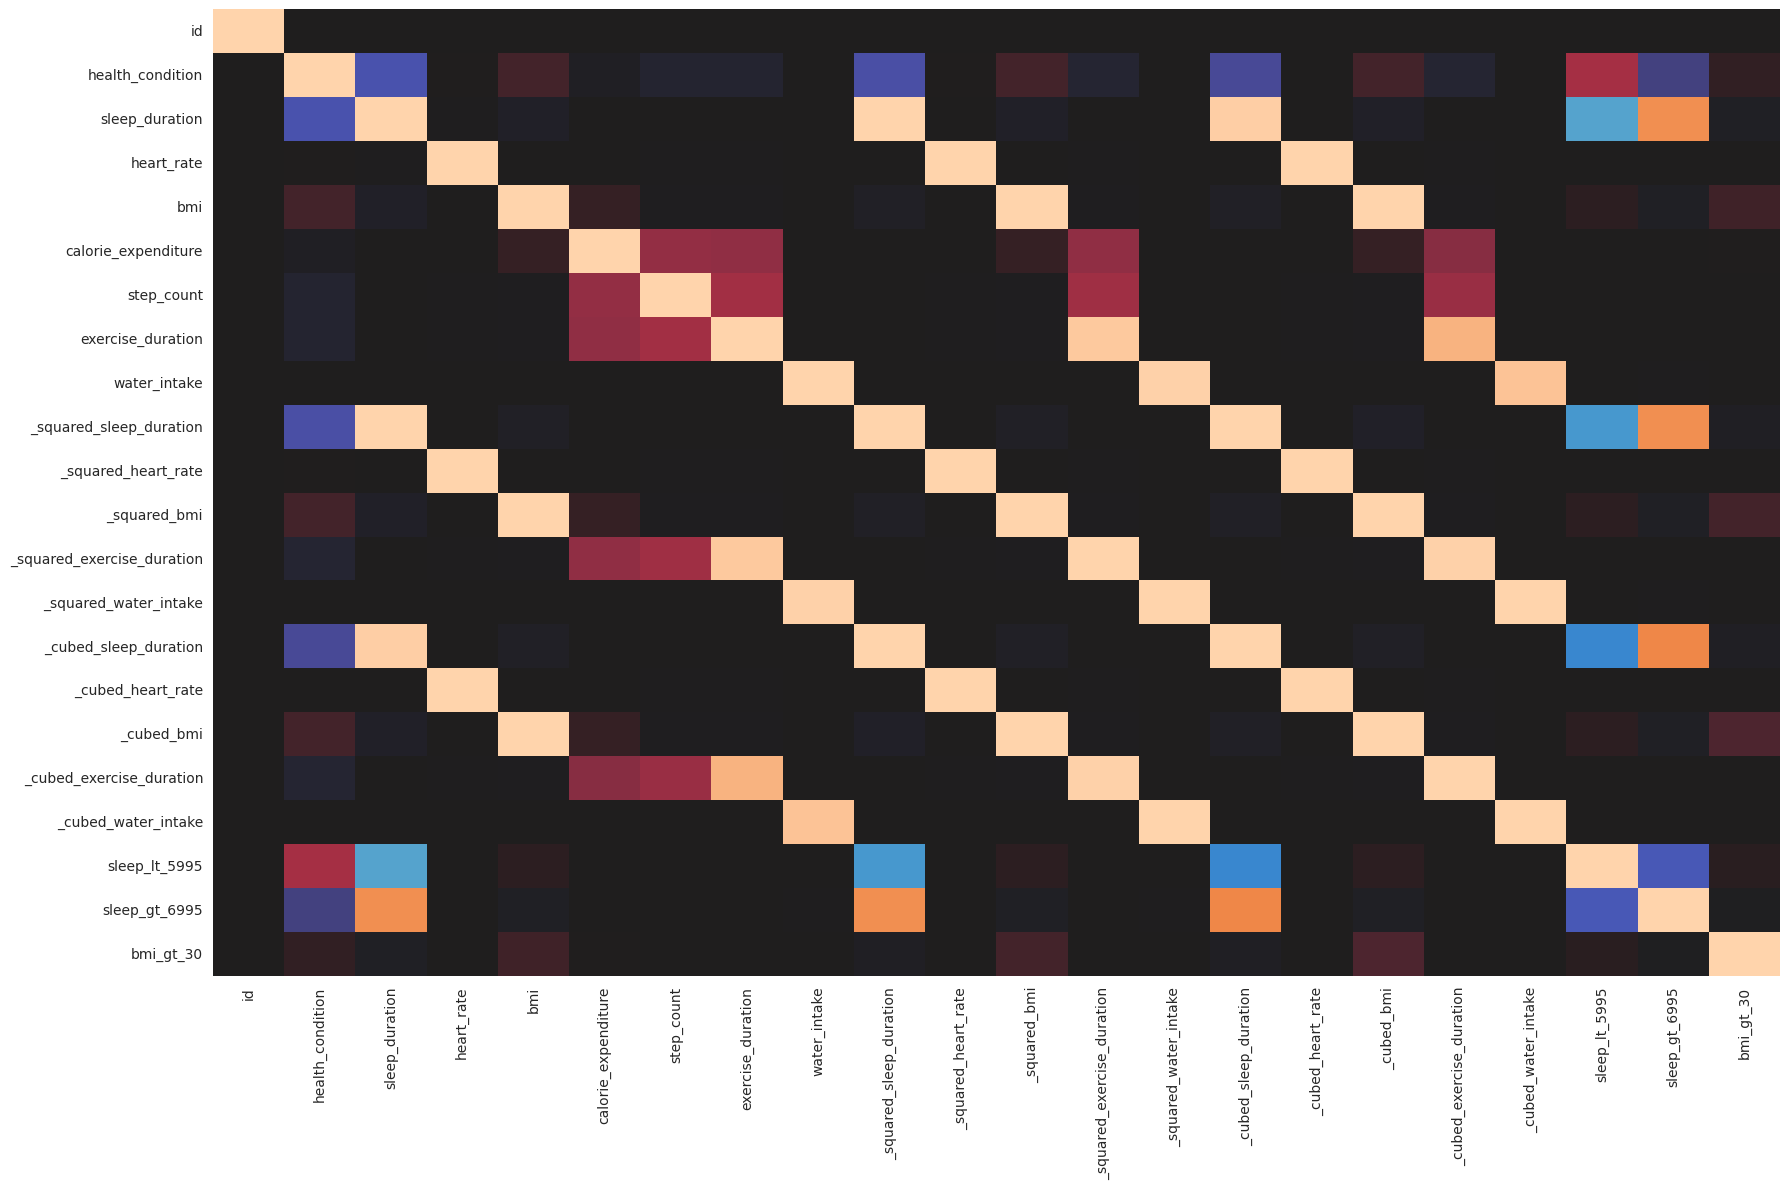

In [32]:
plt.figure(figsize=(18, 12))
sns.heatmap(train.select_dtypes(include='number').corr(), annot=False, cbar=False, fmt='.2f', center=0)

plt.tight_layout()
plt.show()

In [33]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 26


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,_squared_sleep_duration,_squared_heart_rate,_squared_bmi,_squared_exercise_duration,_squared_water_intake,_cubed_sleep_duration,_cubed_heart_rate,_cubed_bmi,_cubed_exercise_duration,_cubed_water_intake,sleep_lt_5995,sleep_gt_6995,bmi_gt_30
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,27.2484,4984.36,658.4356,392.04,3.4596,142.236648,351895.816,16895.457496,7762.392,6.434856,1.0,0.0,0.0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,30.5809,5083.69,667.7056,2490.01,1.5876,169.112377,362467.097,17253.512704,124251.499,2.000376,1.0,0.0,0.0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,27.9841,5685.16,602.2116,1451.61,2.5600,148.035889,428661.064,14778.272664,55306.341,4.096000,1.0,0.0,0.0
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,22.0900,5959.84,534.9969,3588.01,4.0804,103.823000,460099.648,12374.478297,214921.799,8.242408,1.0,0.0,0.0
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,52.2729,5387.56,808.8336,2116.00,5.0625,377.933067,395446.904,23003.227584,97336.000,11.390625,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,39.8161,4858.09,581.2921,948.64,9.0000,251.239591,338608.873,14014.952531,29218.112,27.000000,0.0,0.0,0.0
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,33.4084,2916.00,694.8496,2745.76,2.1316,193.100552,157464.000,18316.235456,143877.824,3.112136,1.0,0.0,0.0
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male,58.3696,7344.49,480.0481,1705.69,2.4649,445.943744,629422.793,10517.853871,70444.997,3.869893,0.0,1.0,0.0
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male,45.4276,5329.00,350.8129,3203.56,6.7600,306.182024,389017.000,6570.725617,181321.496,17.576000,0.0,0.0,0.0


# ML TRAINING

In [34]:
try:
    from venn_abers import VennAbersCalibrator
except:
    %pip install -q venn-abers
    from venn_abers import VennAbersCalibrator

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [35]:
# -- USE_CALIBRATOR --
def Calib_Trainer_CV(model_name, params, train_df, test_df, features, target, kfold,
               one_hot_cats=None, drop=None, with_mean=True, use_priors=False, show_df=True):

    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()
    
    X = train_df[features]
    y = train_df[target]

    num_cls = y.nunique()
    
    ## -- Calculate training class priors (the proportion of each class)
    if use_priors:
        class_priors = y.value_counts(normalize=True).sort_index().values
        print(f"Class priors (sorted by label index): {class_priors.round(4)}")

    oof_preds  = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))

    knn_scores   = []
    fold_scores  = []
    brier_scores = []

    # binary_cols = [c for c in features if X[c].nunique() == 2]

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits} | {get_system_info()} | ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, nunique, max, min
        #     fill_nan=True,
        # )

        # print(f"Category Mean Encoding: {len(cme_features)} | ", end='')
        # cme_enc = CategoryMeanTransformer(cat_cols=[c])
        # X_train[n] = cme_enc.fit_transform(X_train, y_train)
        # X_valid[n] = cme_enc.transform(X_valid)
        # X_test[n]  = cme_enc.transform(X_test)

        # ## -- TE Opt1. -> Using CUSTOM --
        # te_enc  = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        # te_features = [c for c in X_train.columns if c.startswith('TE_')]
        # binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2]
        # no_scale_cols = one_hot_cats+te_features+binary_cols+['RaceProgress']#+freq_cols

        # scale_cols = [c for c in X_train.columns if c not in no_scale_cols]
        
        ## -- Handle missing numeric data --
        # num_cols = [c for c in X_train.columns if c not in one_hot_cats]

        # for col in num_cols:
        #     scaler = StandardScaler()
        #     X_train[col] = scaler.fit_transform(X_train[[col]])
        #     X_test[col]  = scaler.transform(X_test[[col]])
        #     X_valid[col] = scaler.transform(X_valid[[col]])

        #     imputer = IterativeImputer(max_iter=50, tol=1e-5, random_state=0)
        #     X_train[col] = imputer.fit_transform(X_train[[col]])
        #     X_valid[col] = imputer.transform(X_valid[[col]])
        #     X_test[col]  = imputer.transform(X_test[[col]])

        # ## -- Round values --
        # drop_cols = []
        # rounding  = []
        # round_features = ['calorie_expenditure', 'step_count']
        # print(f"Rounding {len(round_features)}... ")
        # for col in round_features:
        #     for r in [-3, -2]:
        #         r_n = f"{col}_round_{r}"
        #         print(r_n + ', ', end='')
        #         X_train[r_n] = X_train[col].round(r).astype('int32')
        #         X_valid[r_n] = X_valid[col].round(r).astype('int32')
        #         X_test[r_n]  = X_test[col].round(r).astype('int32')
        #         # ## -- Drop irrelevant features --
        #         # if X_train[r_n].nunique() < 2 or X_train[r_n].nunique() == X_train[col].nunique():
        #         #     drop_cols.append(r_n)
        #         # else:
        #         rounding.append(r_n)

        # print(X_train[rounding].nunique())
        # ## -- TE only round columns with nunique > 2 --
        # te_rounding = [c for c in rounding if X_train[c].nunique() > 2]
        # print(f" • Target Encoding {len(te_rounding)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_rounding, drop=True)

        # ## -- Drop single value columns --
        # X_train = X_train.drop(columns=drop_cols)
        # X_valid = X_valid.drop(columns=drop_cols)
        # X_test  = X_test.drop(columns=drop_cols)

        ## -- Define encoders --
        scaler_enc  = StandardScaler() if with_mean else StandardScaler(with_mean=False)
        one_h_enc   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
        num_imputer = IterativeImputer(max_iter=100, tol=1e-4, add_indicator=True, random_state=0)
        cat_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)
        ## ------------------------------------------------------------------------
        # num_cols = [c for c in X_train.columns if c not in one_hot_cats]
        num_cols = X_train.columns.difference(one_hot_cats, sort=False)
        # num_cols = list(set(X_train.columns) - set(one_hot_cats))
        
        num_sub_pipeline = Pipeline([('sca', scaler_enc), ('imp', num_imputer)])
        cat_sub_pipeline = Pipeline([('imp', cat_imputer), ('ohe', one_h_enc)])
        preprocessor = ColumnTransformer(transformers=[
            ('num_prep', num_sub_pipeline, num_cols),
            ('cat_prep', cat_sub_pipeline, one_hot_cats)
        ], remainder='passthrough', n_jobs=2)
        ## ------------------------------------------------------------------------
        ## -- Internal split for calibration --
        X_base, X_calib, y_base, y_calib = train_test_split(
            X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
        )

        if 'knn' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, KNeighborsClassifier(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        if 'gaus' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, GaussianNB(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        elif 'bern' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, BernoulliNB(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        elif 'comp' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, ComplementNB(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        elif 'multi' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, MultinomialNB(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        elif 'linear' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, LinearDiscriminantAnalysis(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        elif 'quad' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, QuadraticDiscriminantAnalysis(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        elif 'radius' in model_name:
            print(f"Train shape: {X_base.shape} #####")
            ## -- Create pipeline --
            model = Pipeline([('prep_cols', preprocessor), (model_name, RadiusNeighborsClassifier(**params))])\
                    .set_output(transform='pandas')
            model.fit(X_base, y_base)
            print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
            if show_df and idx==1:
                display(model[:-1].transform(X_calib).head())
        else:
            print(f"\n[⚠️ WARNING] {model_name} not found", file=sys.stderr)

        ## -- Predict on valid and test sets --
        oof_base = model.predict_proba(X_valid)

        # if use_priors:
        #     corr_oof = oof_base / class_priors
        #     oof_base = corr_oof / corr_oof.sum(axis=1, keepdims=True)

        ## -- Fold score --
        base_score = balanced_acc(y_valid, oof_base)
        base_brier = multi_class_brier(y_valid, oof_base, np.unique(y_valid))

        print(f"{CFG['YELLOW']} • Base {idx} acc: {base_score:.5f} | brier: {base_brier:.5f}{CFG['RESET']}")

        print(f"-> Calibrating with venn-abers... ", end="")
        p_cal   = model.predict_proba(X_calib) / class_priors
        p_cal   = p_cal / p_cal.sum(axis=1, keepdims=True)
        
        p_valid = model.predict_proba(X_valid) / class_priors
        p_valid = p_valid / p_valid.sum(axis=1, keepdims=True)

        p_test  = model.predict_proba(X_test) / class_priors
        p_test  = p_test / p_test.sum(axis=1, keepdims=True)

        ## Get calibrated OOF predictions --
        vao = VennAbersCalibrator() 
        oof_calib = vao.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_valid)
        oof_preds[val_idx] = oof_calib

        ## Get calibrated TEST predictions --
        vat = VennAbersCalibrator() 
        test_calib = vat.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_test)
        # test_preds += test_calib / kfold.n_splits

        print(f'✓ Finished!')

        if use_priors:
            corrected_oof = oof_calib / class_priors
            oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)

            corrected_test = test_calib / class_priors
            test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
        else:
            ## -- Predict on validation and test sets --
            oof_preds[val_idx] = oof_calib
            test_preds += test_calib / kfold.n_splits

        ## -- Fold score --
        fold_score = balanced_acc(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
        brier_scores.append(brier_score)

        print(f"{CFG['YELLOW']} • Calib {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

        ## -- Clean up memory -- X_valid, X_train
        # del y_train, y_valid, X_test
        gc.collect()

    # ## -- Average the test predictions
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    total_time = np.round((time() - t0)/60, 4)
    print(f"{total_time} mins")

    return {
        'oof_preds':  oof_preds,
        'test_preds': test_preds,
        'score':      oof_score,
        'model':      model,
        'val_data':   [X_train, X_valid],
        'total_time': total_time,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [36]:
# # -- REGULAR --
# def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold,
#                one_hot_cats=None, drop=None, with_mean=True, use_priors=False, show_df=True):

#     print(f"\n===== Starting CV: {model_name} =====")
#     t0 = time()
    
#     X = train_df[features]
#     y = train_df[target]

#     num_cls = y.nunique()
    
#     ## -- Calculate training class priors (the proportion of each class)
#     if use_priors:
#         class_priors = y.value_counts(normalize=True).sort_index().values
#         print(f"Class priors (sorted by label index): {class_priors.round(4)}")

#     oof_preds  = np.zeros((len(X), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))

#     knn_scores   = []
#     fold_scores  = []
#     brier_scores = []

#     # binary_cols = [c for c in features if X[c].nunique() == 2]

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#         print(f"\n##### FOLD {idx}/{kfold.n_splits} | {get_system_info()} | ", end='')

#         # Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()

#         # ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

#         # ## -- OPTION B: TE Merge original data --
#         # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
#         #     orig,
#         #     X_train,
#         #     X_valid,
#         #     X_test,
#         #     features=BASE,
#         #     target=TARGET,
#         #     aggs=['mean'], # mean, median, count, std, nunique, max, min
#         #     fill_nan=True,
#         # )

#         # print(f"Category Mean Encoding: {len(cme_features)} | ", end='')
#         # cme_enc = CategoryMeanTransformer(cat_cols=[c])
#         # X_train[n] = cme_enc.fit_transform(X_train, y_train)
#         # X_valid[n] = cme_enc.transform(X_valid)
#         # X_test[n]  = cme_enc.transform(X_test)

#         # ## -- TE Opt1. -> Using CUSTOM --
#         # te_enc  = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
#         # X_train = te_enc.fit_transform(X_train, y_train)
#         # X_valid = te_enc.transform(X_valid)
#         # X_test  = te_enc.transform(X_test)

#         # te_features = [c for c in X_train.columns if c.startswith('TE_')]
#         # binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2]
#         # no_scale_cols = one_hot_cats+te_features+binary_cols+['RaceProgress']#+freq_cols

#         # scale_cols = [c for c in X_train.columns if c not in no_scale_cols]
        
#         ## -- Handle missing numeric data --
#         # num_cols = [c for c in X_train.columns if c not in one_hot_cats]

#         # for col in num_cols:
#         #     scaler = StandardScaler()
#         #     X_train[col] = scaler.fit_transform(X_train[[col]])
#         #     X_test[col]  = scaler.transform(X_test[[col]])
#         #     X_valid[col] = scaler.transform(X_valid[[col]])

#         #     imputer = IterativeImputer(max_iter=50, tol=1e-5, random_state=0)
#         #     X_train[col] = imputer.fit_transform(X_train[[col]])
#         #     X_valid[col] = imputer.transform(X_valid[[col]])
#         #     X_test[col]  = imputer.transform(X_test[[col]])

#         # ## -- Round values --
#         # drop_cols = []
#         # rounding  = []
#         # round_features = ['calorie_expenditure', 'step_count']
#         # print(f"Rounding {len(round_features)}... ")
#         # for col in round_features:
#         #     for r in [-3, -2]:
#         #         r_n = f"{col}_round_{r}"
#         #         print(r_n + ', ', end='')
#         #         X_train[r_n] = X_train[col].round(r).astype('int32')
#         #         X_valid[r_n] = X_valid[col].round(r).astype('int32')
#         #         X_test[r_n]  = X_test[col].round(r).astype('int32')
#         #         # ## -- Drop irrelevant features --
#         #         # if X_train[r_n].nunique() < 2 or X_train[r_n].nunique() == X_train[col].nunique():
#         #         #     drop_cols.append(r_n)
#         #         # else:
#         #         rounding.append(r_n)

#         # print(X_train[rounding].nunique())
#         # ## -- TE only round columns with nunique > 2 --
#         # te_rounding = [c for c in rounding if X_train[c].nunique() > 2]
#         # print(f" • Target Encoding {len(te_rounding)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_rounding, drop=True)

#         # ## -- Drop single value columns --
#         # X_train = X_train.drop(columns=drop_cols)
#         # X_valid = X_valid.drop(columns=drop_cols)
#         # X_test  = X_test.drop(columns=drop_cols)

#         ## -- Define encoders --
#         scaler_enc  = StandardScaler() if with_mean else StandardScaler(with_mean=False)
#         one_h_enc   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
#         num_imputer = IterativeImputer(max_iter=100, tol=1e-4, add_indicator=True, random_state=0)
#         cat_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)
#         ## ------------------------------------------------------------------------
#         # num_cols = [c for c in X_train.columns if c not in one_hot_cats]
#         num_cols = X_train.columns.difference(one_hot_cats, sort=False)
#         # num_cols = list(set(X_train.columns) - set(one_hot_cats))
        
#         num_sub_pipeline = Pipeline([('sca', scaler_enc), ('imp', num_imputer)])
#         cat_sub_pipeline = Pipeline([('imp', cat_imputer), ('ohe', one_h_enc)])
#         preprocessor = ColumnTransformer(transformers=[
#             ('num_prep', num_sub_pipeline, num_cols),
#             ('cat_prep', cat_sub_pipeline, one_hot_cats)
#         ], remainder='passthrough', n_jobs=2)
#         ## ------------------------------------------------------------------------

#         if 'knn' in model_name:
#             ## -- Internal split for calibration --
#             X_base, X_calib, y_base, y_calib = train_test_split(
#                 X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
#             )
#             print(f"Train shape: {X_base.shape} #####")

#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, KNeighborsClassifier(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_base, y_base)
#             print(f"-> Total features used by KNN: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_calib).head())

#             ## -- Predict on valid and test sets --
#             oof_base = model.predict_proba(X_valid)

#             # if use_priors:
#             #     corr_oof = oof_base / class_priors
#             #     oof_base = corr_oof / corr_oof.sum(axis=1, keepdims=True)

#             ## -- Fold score --
#             base_score = balanced_acc(y_valid, oof_base)
#             base_brier = multi_class_brier(y_valid, oof_base, np.unique(y_valid))

#             print(f"{CFG['YELLOW']} • Base {idx} acc: {base_score:.5f} | brier: {base_brier:.5f}{CFG['RESET']}")

#             print(f"-> Calibrating with venn-abers... ", end="")
#             p_cal   = model.predict_proba(X_calib) / class_priors
#             p_cal   = p_cal / p_cal.sum(axis=1, keepdims=True)
            
#             p_valid = model.predict_proba(X_valid) / class_priors
#             p_valid = p_valid / p_valid.sum(axis=1, keepdims=True)

#             p_test  = model.predict_proba(X_test) / class_priors
#             p_test  = p_test / p_test.sum(axis=1, keepdims=True)

#             ## Get calibrated OOF predictions --
#             vao = VennAbersCalibrator() 
#             oof_calib = vao.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_valid)
#             oof_preds[val_idx] = oof_calib

#             ## Get calibrated TEST predictions --
#             vat = VennAbersCalibrator() 
#             test_calib = vat.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_test)
#             # test_preds += test_calib / kfold.n_splits

#             print(f'✓ Finished!')

#             if use_priors:
#                 corrected_oof = oof_calib / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)

#                 corrected_test = test_calib / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = oof_calib
#                 test_preds += test_calib / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)

#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)

#             print(f"{CFG['YELLOW']} • Calib {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         elif 'gaus' in model_name:
#             print(f"Train shape: {X_train.shape} *****")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, GaussianNB(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         elif 'bern' in model_name:
#             print(f"Train shape: {X_train.shape} *****")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, BernoulliNB(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         elif 'comp' in model_name:
#             print(f"Train shape: {X_train.shape} *****")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, ComplementNB(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         elif 'multi' in model_name:
#             print(f"Train shape: {X_train.shape} *****")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, MultinomialNB(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         elif 'linear' in model_name:
#             print(f"Train shape: {X_train.shape} *****")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, LinearDiscriminantAnalysis(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         elif 'quad' in model_name:
#             print(f"Train shape: {X_train.shape} *****")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, QuadraticDiscriminantAnalysis(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         elif 'radius' in model_name:
#             print(f"Train shape: {X_train.shape} *****")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, RadiusNeighborsClassifier(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features by {model_name}: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
#         else:
#             print(f"shape: {X_train.shape} #####")
#             ## -- Create pipeline --
#             model = Pipeline([('prep_cols', preprocessor), (model_name, LogisticRegression(**params))])\
#                     .set_output(transform='pandas')
#             model.fit(X_train, y_train)
#             print(f"-> Total features used by Logistic model: {len(model[:-1].get_feature_names_out())}")
#             if show_df and idx==1:
#                 display(model[:-1].transform(X_train).head())

#             if use_priors:
#                 oof_predictions = model.predict_proba(X_valid)
#                 corrected_oof = oof_predictions / class_priors
#                 oof_preds[val_idx] = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
        
#                 test_predictions = model.predict_proba(X_test)
#                 # display(test_predictions[:5])
#                 corrected_test = test_predictions / class_priors
#                 test_preds += (corrected_test / corrected_test.sum(axis=1, keepdims=True)) / kfold.n_splits
#             else:
#                 ## -- Predict on validation and test sets --
#                 oof_preds[val_idx] = model.predict_proba(X_valid)
#                 test_preds += model.predict_proba(X_test) / kfold.n_splits

#             ## -- Fold score --
#             fold_score = balanced_acc(y_valid, oof_preds[val_idx])
#             fold_scores.append(fold_score)
    
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
#             brier_scores.append(brier_score)
    
#             print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

#         ## -- Clean up memory -- X_valid, X_train
#         # del y_train, y_valid, X_test
#         gc.collect()

#     # ## -- Average the test predictions
#     # test_preds /= kfold.n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(balanced_acc(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     total_time = np.round((time() - t0)/60, 4)
#     print(f"{total_time} mins")

#     return {
#         'oof_preds':  oof_preds,
#         'test_preds': test_preds,
#         'score':      oof_score,
#         'model':      model,
#         'val_data':   [X_train, X_valid],
#         'total_time': total_time,
#     }

# print("⚙️ Training function ready ⚙️")

In [37]:
all_predictions = {}

MULTI_SEEDS  = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS + FLAG_COLS

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN  = True
USE_CALIBRATION = False
x_sample, x_sample2 = train_test_split(train, train_size=0.2, stratify=train[TARGET], random_state=0)

train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()
train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,_squared_sleep_duration,_squared_heart_rate,_squared_bmi,_squared_exercise_duration,_squared_water_intake,_cubed_sleep_duration,_cubed_heart_rate,_cubed_bmi,_cubed_exercise_duration,_cubed_water_intake,sleep_lt_5995,sleep_gt_6995,bmi_gt_30
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,27.2484,4984.36,658.4356,392.04,3.4596,142.236648,351895.816,16895.457496,7762.392,6.434856,1.0,0.0,0.0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,30.5809,5083.69,667.7056,2490.01,1.5876,169.112377,362467.097,17253.512704,124251.499,2.000376,1.0,0.0,0.0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,27.9841,5685.16,602.2116,1451.61,2.5600,148.035889,428661.064,14778.272664,55306.341,4.096000,1.0,0.0,0.0
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,22.0900,5959.84,534.9969,3588.01,4.0804,103.823000,460099.648,12374.478297,214921.799,8.242408,1.0,0.0,0.0
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,52.2729,5387.56,808.8336,2116.00,5.0625,377.933067,395446.904,23003.227584,97336.000,11.390625,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,39.8161,4858.09,581.2921,948.64,9.0000,251.239591,338608.873,14014.952531,29218.112,27.000000,0.0,0.0,0.0
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,33.4084,2916.00,694.8496,2745.76,2.1316,193.100552,157464.000,18316.235456,143877.824,3.112136,1.0,0.0,0.0
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male,58.3696,7344.49,480.0481,1705.69,2.4649,445.943744,629422.793,10517.853871,70444.997,3.869893,0.0,1.0,0.0
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male,45.4276,5329.00,350.8129,3203.56,6.7600,306.182024,389017.000,6570.725617,181321.496,17.576000,0.0,0.0,0.0


In [38]:
## ========== GaussianNB
naive_bayes = [
    ("gausNB", {'priors': None}),
    # ("bernNB", {'alpha': 1.0, 'force_alpha': True}),
    # ("compNB", {'alpha': 1.0, 'force_alpha': True}),
    # ("multiNB", {'alpha': 1.0, 'force_alpha': True}),
    # ("linearDA", {'shrinkage': 'auto'}),
    # ("quadDA", {'shrinkage': 'auto'}),
    # ("radiusNC", {'radius': 1.0, 'weights': 'uniform', 'n_jobs': 64 if os.cpu_count() > 4 else 3}),
]

for n, params in tqdm(naive_bayes, total=len(naive_bayes)):
    all_predictions[n] = Calib_Trainer_CV(
        model_name=n,
        params=params,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        one_hot_cats=ALL_CATS,
        drop='if_binary', # def=None
        # with_mean=False, # def=True
        use_priors=True, # def=False
    )

  0%|          | 0/1 [00:00<?, ?it/s]


===== Starting CV: gausNB =====
Class priors (sorted by label index): [0.0577 0.8587 0.0836]

##### FOLD 1/5 | CPU: 4 | Train shape: (386449, 26) #####


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


-> Total features by gausNB: 61


,num_prep__sleep_duration,num_prep__heart_rate,num_prep__bmi,num_prep__calorie_expenditure,num_prep__step_count,num_prep__exercise_duration,num_prep__water_intake,num_prep___squared_sleep_duration,num_prep___squared_heart_rate,num_prep___squared_bmi,num_prep___squared_exercise_duration,num_prep___squared_water_intake,num_prep___cubed_sleep_duration,num_prep___cubed_heart_rate,num_prep___cubed_bmi,num_prep___cubed_exercise_duration,num_prep___cubed_water_intake,num_prep__missingindicator_sleep_duration,num_prep__missingindicator_heart_rate,num_prep__missingindicator_bmi,num_prep__missingindicator_calorie_expenditure,num_prep__missingindicator_step_count,num_prep__missingindicator_exercise_duration,num_prep__missingindicator_water_intake,num_prep__missingindicator__squared_sleep_duration,num_prep__missingindicator__squared_heart_rate,num_prep__missingindicator__squared_bmi,num_prep__missingindicator__squared_exercise_duration,num_prep__missingindicator__squared_water_intake,num_prep__missingindicator__cubed_sleep_duration,num_prep__missingindicator__cubed_heart_rate,num_prep__missingindicator__cubed_bmi,num_prep__missingindicator__cubed_exercise_duration,num_prep__missingindicator__cubed_water_intake,cat_prep__diet_type_balanced,cat_prep__diet_type_non-veg,cat_prep__diet_type_veg,cat_prep__stress_level_high,cat_prep__stress_level_low,cat_prep__stress_level_medium,cat_prep__sleep_quality_average,cat_prep__sleep_quality_good,cat_prep__sleep_quality_poor,cat_prep__physical_activity_level_active,cat_prep__physical_activity_level_moderate,cat_prep__physical_activity_level_sedentary,cat_prep__smoking_alcohol_no,cat_prep__smoking_alcohol_occasional,cat_prep__smoking_alcohol_yes,cat_prep__gender_female,cat_prep__gender_male,cat_prep__gender_other,cat_prep__sleep_lt_5995_1.0,cat_prep__sleep_gt_6995_1.0,cat_prep__bmi_gt_30_1.0,cat_prep__missingindicator_diet_type_True,cat_prep__missingindicator_stress_level_True,cat_prep__missingindicator_sleep_quality_True,cat_prep__missingindicator_physical_activity_level_True,cat_prep__missingindicator_smoking_alcohol_True,cat_prep__missingindicator_gender_True
611705,1.421736,0.647561,-0.992258,1.305213,0.367925,1.916116,-2.154541,1.501349,0.614275,-0.989066,2.511228,-1.673062,1.544785,0.572921,-0.973114,2.963705,-1.283430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
329190,-1.646886,-1.344713,1.134457,1.127007,-0.406116,-0.842885,-0.053629,-1.488960,-1.297188,1.145267,-0.930017,-0.166906,-1.322546,-1.239337,1.142001,-0.868116,-0.253234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
178206,0.056076,-1.821392,-0.629062,0.451548,0.388281,1.102652,-0.805331,-0.030390,-1.690599,-0.658950,1.184504,-0.822595,-0.111099,-1.558938,-0.678054,1.141332,-0.780683,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
447193,-0.166050,-1.014704,-0.253759,1.058024,0.883952,0.045148,-0.323471,-0.249057,-1.010365,-0.302952,-0.150050,-0.417255,-0.317841,-0.994000,-0.345986,-0.285399,-0.466809,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
162852,2.441868,0.317552,0.109437,0.417057,-0.696953,-1.195386,-0.458392,2.855815,0.267853,0.055959,-1.153385,-0.536140,3.274290,0.215049,0.002784,-0.987415,-0.563110,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


...

-> Total features by gausNB: 61
 • Base 3 acc: 0.83694 | brier: 0.48184
-> Calibrating with venn-abers... ✓ Finished!
 • Calib 3 acc: 0.85606 | brier: 0.24202

##### FOLD 4/5 | CPU: 4 | Train shape: (386449, 26) #####


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


-> Total features by gausNB: 61
 • Base 4 acc: 0.83716 | brier: 0.48300
-> Calibrating with venn-abers... ✓ Finished!
 • Calib 4 acc: 0.85261 | brier: 0.24392

##### FOLD 5/5 | CPU: 4 | Train shape: (386449, 26) #####


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


-> Total features by gausNB: 61
 • Base 5 acc: 0.83628 | brier: 0.47907
-> Calibrating with venn-abers... ✓ Finished!
 • Calib 5 acc: 0.85199 | brier: 0.25307

5-FOLD CV: gausNB
 • Fold 1 score: 0.85312 | brier: 0.25053
 • Fold 2 score: 0.85443 | brier: 0.24925
 • Fold 3 score: 0.85606 | brier: 0.24202
 • Fold 4 score: 0.85261 | brier: 0.24392
 • Fold 5 score: 0.85199 | brier: 0.25307
-------------------------------------------------|
OOF score: 0.85364
AVG score: 0.85364 ± 0.00145
-------------------------------------------------|
OOF brier: 0.24776
AVG brier: 0.24776 ± 0.00414
-------------------------------------------------|
59.879 mins


In [39]:
# ==================================================
# 5-FOLD CV: gaussianNB
# ==================================================
#  • Fold 1 score: 0.83286 | brier: 0.28167
#  • Fold 2 score: 0.83412 | brier: 0.28441
#  • Fold 3 score: 0.83508 | brier: 0.28251
#  • Fold 4 score: 0.83004 | brier: 0.28794
#  • Fold 5 score: 0.83238 | brier: 0.28751
# -------------------------------------------------|
# OOF score: 0.8329
# AVG score: 0.83290 ± 0.00172
# -------------------------------------------------|
# OOF brier: 0.28481
# AVG brier: 0.28481 ± 0.00255
# -------------------------------------------------|
# 1.0522 mins

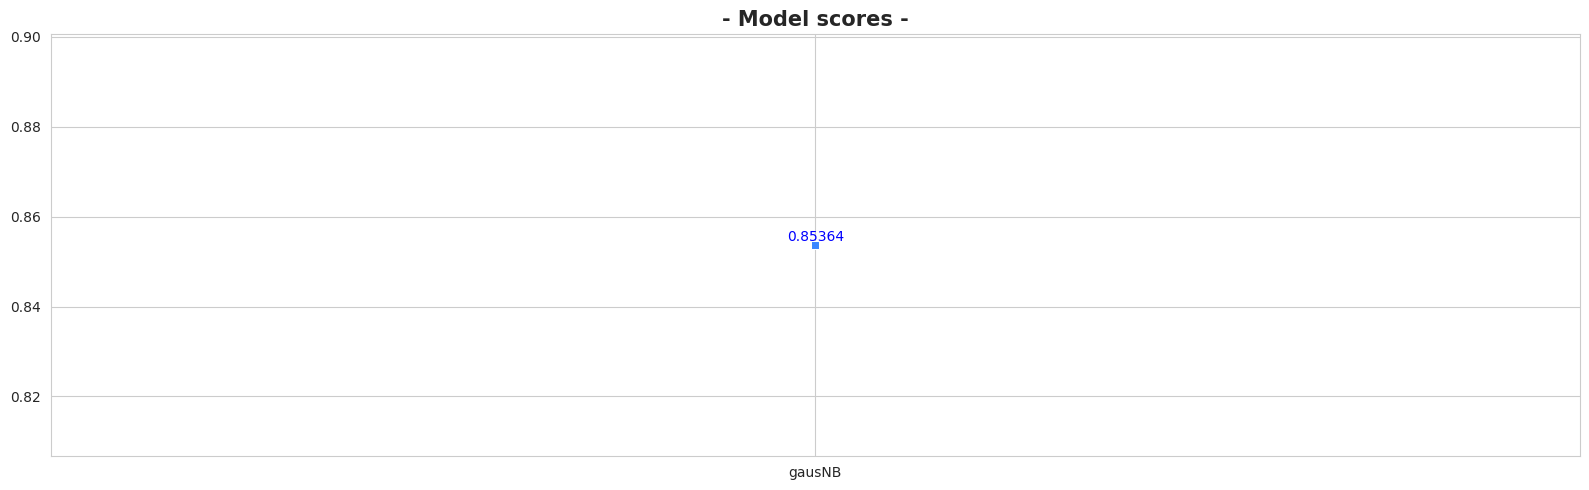

In [40]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot([*all_scores.values()], marker="s")

y_add = 1e-3

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline", color="b")

# plt.ylim((0.94, 0.955))
# plt.legend(loc='best')
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title("- Model scores -", fontdict={"weight": "semibold", "size": 15})

plt.tight_layout()
plt.show()


gausNB_85364 saved!


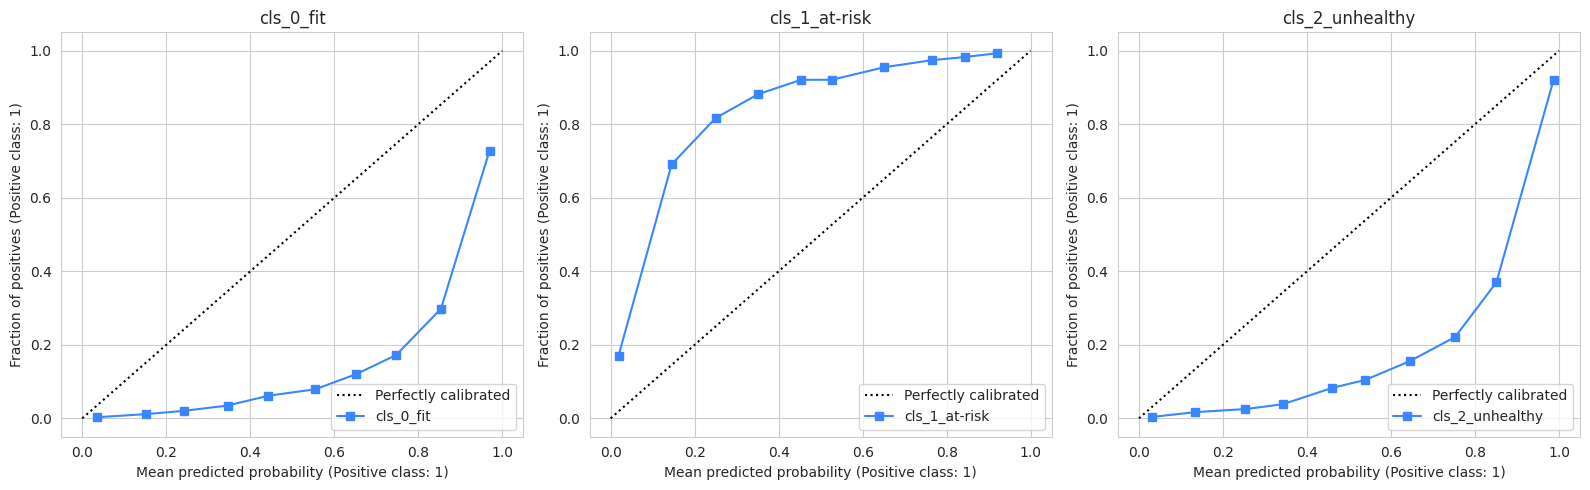

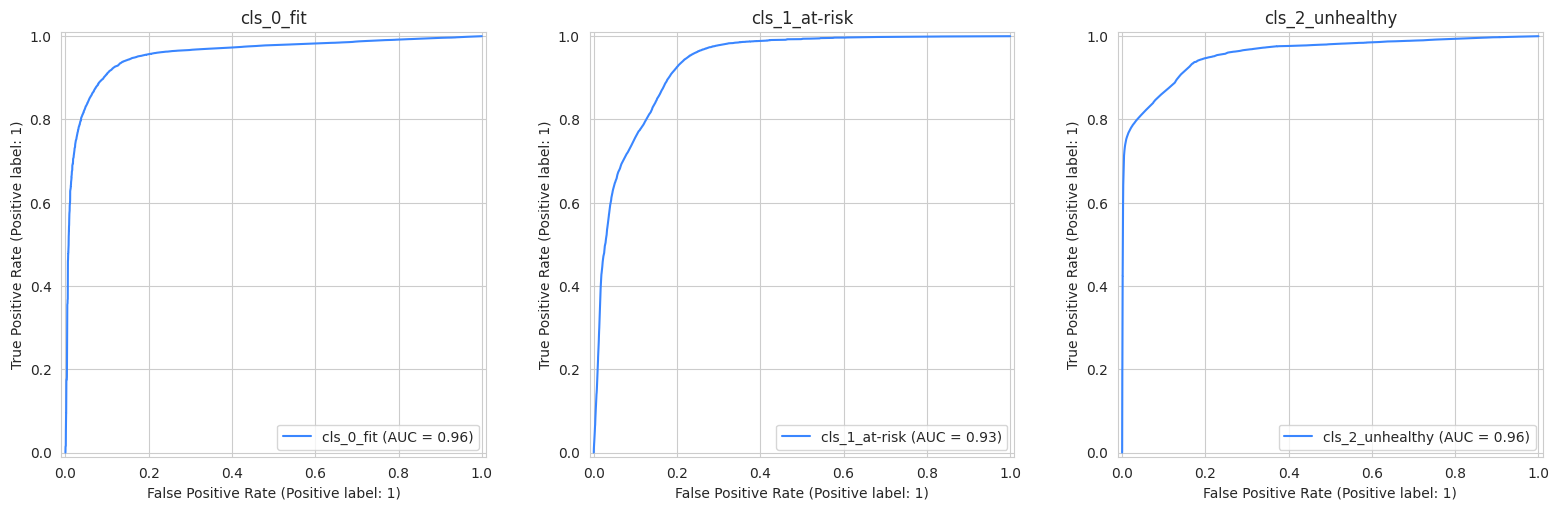

In [41]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print()
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            classes = [*mapping.keys()]
            name0 = f"cls_0_{classes[0]}"
            name1 = f"cls_1_{classes[1]}"
            name2 = f"cls_2_{classes[2]}"

            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

gausNB_85364 saved! (295753, 3)


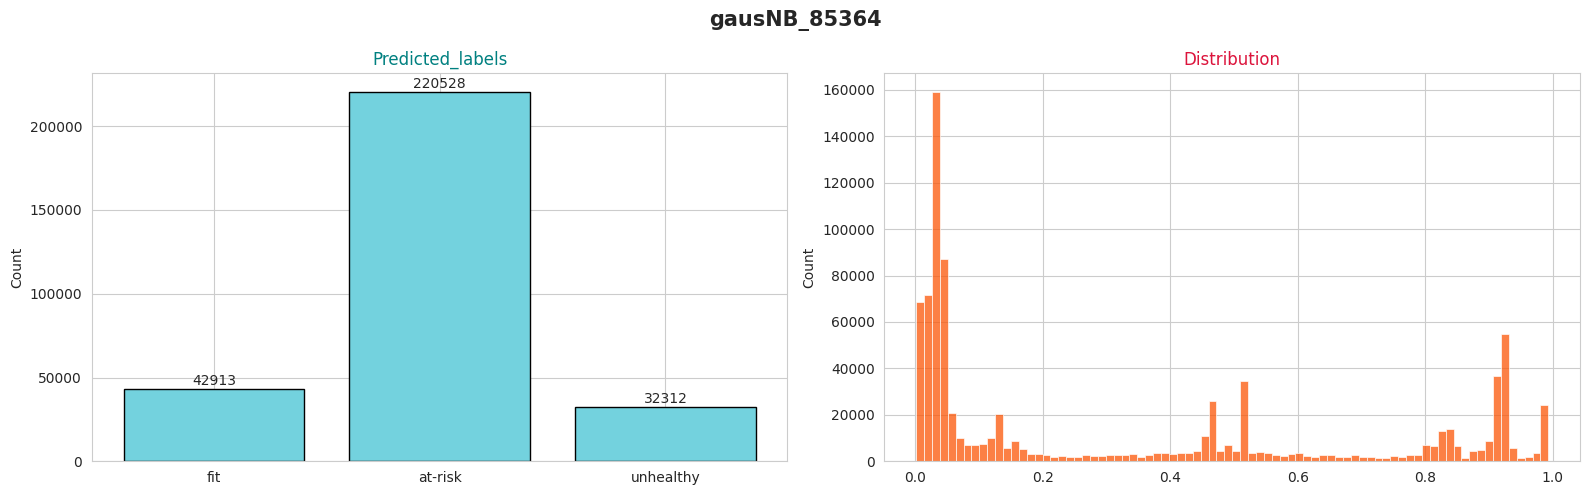

In [42]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(mapping))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title("Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title("Distribution", color='crimson')

            plt.suptitle(n, fontsize=15, fontweight='semibold')

            plt.tight_layout()
            plt.show()

            print()

In [43]:
pd.DataFrame(model_results)

,gausNB_85364
0,unhealthy
1,at-risk
2,at-risk
3,at-risk
4,unhealthy
...,...
295748,fit
295749,at-risk
295750,at-risk
295751,at-risk


In [44]:
# load_sample = np.load("/kaggle/working/test_knn_87175_.npy")
# load_sample[:5]

In [45]:
try:
    import shap
except:
    %pip install -q -U shap
    import shap

print(f"Shap version: {shap.__version__}")

Shap version: 0.51.0


PermutationExplainer explainer: 101it [00:10,  2.05s/it]                        


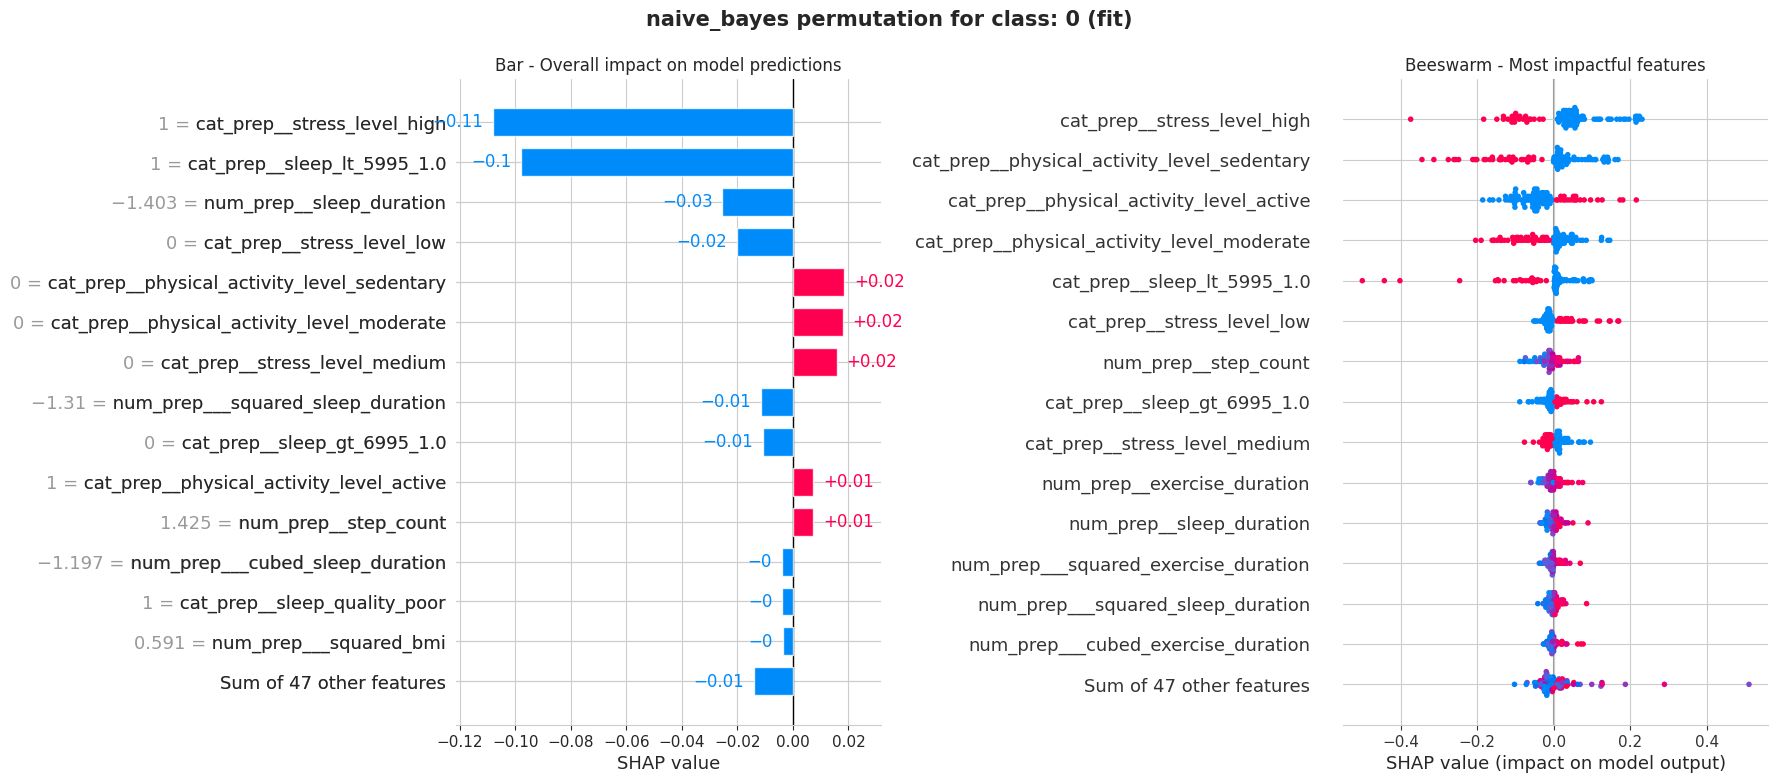

In [46]:
## -- SHAP values: Feature Importances--
naive_ = all_predictions[list(all_predictions.keys())[0]]
# distance_ = all_predictions[list(all_predictions.keys())[-2]]
# neighbors_ = all_predictions[list(all_predictions.keys())[-1]]

models = [
    ('naive_bayes', naive_),
    # ('distant_analysis', distance_),
    # ('radius_neighbors', neighbors_),
]

max_display = 15
class_id = 0
instance_id = 0

for i, (n, m) in enumerate(models):
    model   = m['model'][-1]
    x_train = m['model'][:-1].transform(m['val_data'][0])
    x_valid = m['model'][:-1].transform(m['val_data'][1])

    ## -- Shap Explainer --
    def f(x):
        return model.predict_proba(x)

    x_med = x_train
    explainer = shap.Explainer(f, x_med)
    explanation = explainer(x_valid[:100])

    ## -- Bar plot --
    plt.subplot(121)
    shap.plots.bar(explanation[instance_id, :, class_id], max_display=max_display, show=False)
    plt.title('Bar - Overall impact on model predictions')

    ## -- Beeswarm plot --
    plt.subplot(122)
    shap.plots.beeswarm(
        explanation[:, :, class_id], #order=explanation.abs.max(0),
        plot_size=(18, 8), max_display=max_display, color_bar=False, show=False)
    plt.title('Beeswarm - Most impactful features')

    plt.suptitle(f"{n} permutation for class: {class_id} ({r_mapping[class_id]})",
                 fontsize=15, fontweight='semibold')
    plt.tight_layout(pad=1.5)
    plt.show()
    print()

# HILLCLIMB

In [47]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     %pip install -q -U hillclimbers
#     from hillclimbers import climb_hill, partial

# ## -- Load data --
# oof_df = pd.DataFrame()
# test_df = pd.DataFrame()

# print('Loading data: ', end='')
# for (root, dirs, files) in os.walk('/kaggle/working'):
#     for i, file in enumerate(sorted(files), 1):
#         if i%5 == 0: print(f'{i}%.. ', end='')
#         if file.endswith('.npy') and 'oof' in file:
#             oof_df = pd.concat([oof_df, pd.Series(np.load(os.path.join(root, file)),
#                                 name=file[4:-4])], axis=1)
#         elif file.endswith('.npy') and 'test' in file:
#             test_df = pd.concat([test_df, pd.Series(np.load(os.path.join(root, file)),
#                                 name=file[5:-4])], axis=1)

# print(CFG.YELLOW)
# print(f"OOF  loaded : {oof_df.shape}")
# print(f"TEST loaded : {test_df.shape}")

# display(oof_df.head())
# display(test_df.head())

In [48]:
# %%time

# trn = pd.read_csv(PATH+'train.csv').drop(columns=['id'])

# pred_hc, oof_hc = climb_hill(
#                                train = trn,
#                               target = TARGET,
#                          oof_pred_df = oof_df,
#                         test_pred_df = test_df,
#                            objective = 'maximize',
#                          eval_metric = partial(roc_auc_score),
#                     # negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.01,
#                            plot_hill = True,
#                            plot_hist = True,
# )

In [49]:
# hc_auc = str(round(roc_auc_score(train[TARGET], oof_hc), 5)).split('.')[1]
# print(f"Hillclimb score: {hc_auc}")

# n = 'log-knn-mlp'
# np.save(f"oof_{n}_hillclimb_{hc_auc}.npy", oof_hc)
# np.save(f"test_{n}_hillclimb_{hc_auc}.npy", pred_hc)

# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_{n}_hillclimb_{hc_auc}.csv", index=False)
# print(f"\n✅ Saved hillclimb ensemble!!!")

# submit.head(10)